In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# load library
from sklearn.datasets import load_iris

#import IRIS dataset
iris = load_iris()
# Describe the data
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
x = iris.data
y = iris.target
features = iris.feature_names
target = iris.target_names

print("Feature Names:",features)
print("-"*100)
print("Target Names:", target)
print("-"*100)
print("data:", x[:10])
print("-"*100)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
----------------------------------------------------------------------------------------------------
Target Names: ['setosa' 'versicolor' 'virginica']
----------------------------------------------------------------------------------------------------
data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
----------------------------------------------------------------------------------------------------


In [5]:
# checking shape of dataset before spliting
print(x.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

# spliting data in test and train set keeping 70% data in train set and 30% data in test set. 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 1)

(150, 4)
(150,)


In [6]:
# checking shape of dataset "after" spliting
print("Train Data Details")
print(X_train.shape)
print(X_test.shape)

print("-"*50)

print("Test Data Details")
print(y_train.shape)
print(y_test.shape)

Train Data Details
(112, 4)
(38, 4)
--------------------------------------------------
Test Data Details
(112,)
(38,)


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

<class 'sklearn.tree._tree.Tree'>
{'criterion': 'gini', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_weight_fraction_leaf': 0.0, 'max_features': None, 'max_leaf_nodes': None, 'random_state': None, 'min_impurity_decrease': 0.0, 'class_weight': None, 'ccp_alpha': 0.0, 'monotonic_cst': None, 'n_features_in_': 4, 'n_outputs_': 1, 'classes_': array([0, 1, 2]), 'n_classes_': np.int64(3), 'max_features_': 4, 'tree_': <sklearn.tree._tree.Tree object at 0x0000012AE2B35990>}


<Axes: >

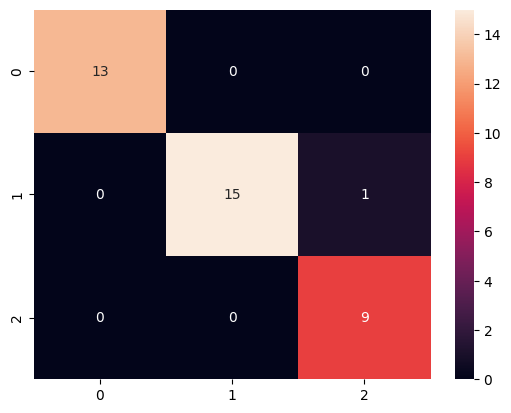

In [33]:
# DT Classifier
dt = DecisionTreeClassifier()
#print(dt.__dict__)

# Lets fit the data into classifier 
dt.fit(X_train, y_train)
print(type(dt.tree_))
print(dt.__dict__)

# predict on test data
y_pred = dt.predict(X_test)

#confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)


# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True)

In [10]:
# let's check Classification accuracy
print( "Classification Accuracy:  ", dt.score(X_test, y_test))

print("*"*50)

# Recall Score
from sklearn.metrics import recall_score
print("Recall Score: ", recall_score(y_test, y_pred, average='macro'))

print("*"*50)

# Precision Score
from sklearn.metrics import precision_score
print("Precision Score: ", precision_score(y_test, y_pred, average='macro'))


print("*"*50)

# F1 Score 
# f1 Score = 2 * (precision * recall) / (precision + recall)

from sklearn.metrics import f1_score
print("F1 Score", f1_score(y_test, y_pred, average='macro'))

Classification Accuracy:   0.9736842105263158
**************************************************
Recall Score:  0.9791666666666666
**************************************************
Precision Score:  0.9666666666666667
**************************************************
F1 Score 0.9717034521788341


In [11]:
from sklearn.svm import LinearSVC

#Linear SVC Classifier
clf = LinearSVC(penalty='l2', loss='squared_hinge', dual=True, C=100, multi_class='ovr')

# Fitting training data into classifier
clf.fit(X_train,y_train)

# Accuracy
print('Accuracy of linear SVC on training set: {:.2f}'.format(clf.score(X_train, y_train) * 100))
print('Accuracy of linear SVC on test set: {:.2f}'.format(clf.score(X_test, y_test) *100))

y_pred = clf.predict(X_test)

Accuracy of linear SVC on training set: 94.64
Accuracy of linear SVC on test set: 100.00


e:\Document backup\pythonfastapi\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<Axes: >

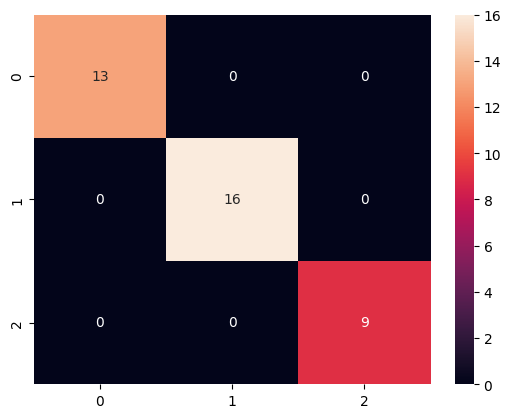

In [12]:
#confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True)

In [13]:
# Recall Score
from sklearn.metrics import recall_score
print("Recall Score: ", recall_score(y_test, y_pred, average='macro'))

print("*"*50)

# Precision Score
from sklearn.metrics import precision_score
print("Precision Score: ", precision_score(y_test, y_pred, average='macro'))


print("*"*50)

# F1 Score 
# f1 Score = 2 * (precision * recall) / (precision + recall)

from sklearn.metrics import f1_score
print("F1 Score", f1_score(y_test, y_pred, average='macro'))

Recall Score:  1.0
**************************************************
Precision Score:  1.0
**************************************************
F1 Score 1.0


In [14]:
from sklearn.svm import SVC

# SVC Classifier
clf_SVC = SVC(C=100.0, kernel='rbf', degree=3, gamma='auto', coef0=0.0, shrinking=True, 
          probability=False, tol=0.001, cache_size=200, class_weight=None, 
          verbose=0, max_iter=-1, decision_function_shape="ovr", random_state = 0)

# Fitting training data
clf_SVC.fit(X_train,y_train)

# predictions
y_pred = clf_SVC.predict(X_test)

# predicting accuracies
print('Accuracy of SVC on training set: {:.2f}'.format(clf_SVC.score(X_train, y_train) * 100))

print('Accuracy of SVC on test set: {:.2f}'.format(clf_SVC.score(X_test, y_test) * 100))

Accuracy of SVC on training set: 98.21
Accuracy of SVC on test set: 97.37


<Axes: >

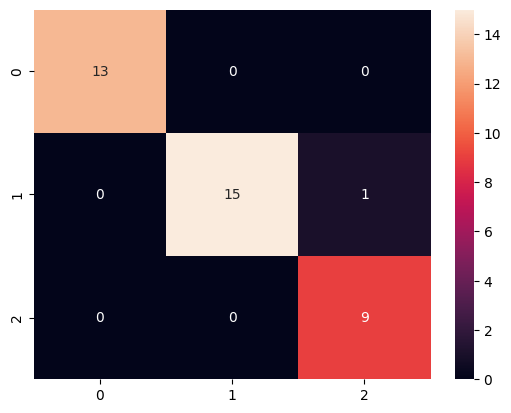

In [15]:
#confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True)